# 🔄 Multi-Adapter QLoRA — 3 Real-World Adapters on One Model

One frozen **Qwen2.5-0.5B** base model. Three swappable adapters. Three completely different experts.

| Adapter | Source | Task | Output format |
|---------|--------|------|---------------|
| 🏥 Appointment Intent | From your workshop notebook | Classify user message into 1 of 9 intents | Single intent label |
| 💬 Complaint Handler | New | Analyse and respond to customer complaints | SEVERITY / EMOTION / RESPONSE |
| 🐛 Code Bug Explainer | New | Explain buggy code in plain English | BUG / CAUSE / FIX |

**The payoff slide:** `model.set_adapter("appointment_intent")` ← one line switches the entire model's expertise.


## Step 1 — Install & Imports

In [ ]:
!pip install -q transformers trl peft datasets bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.9 MB/s eta 0:00:00


In [ ]:
import os, json, time, warnings, inspect
import torch, trl, pandas as pd
from datasets import Dataset
from IPython.display import display, HTML
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel, TaskType
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    g = torch.cuda.get_device_properties(0)
    print(f"GPU: {g.name}  |  VRAM: {g.total_memory/1e9:.1f} GB  |  TRL {trl.__version__}")
else:
    print("No GPU — Runtime → Change runtime type → T4 GPU")


GPU: Tesla T4  |  VRAM: 15.6 GB  |  TRL 1.4.0


## Step 2 — Config

In [ ]:
MODEL_ID     = "Qwen/Qwen2.5-0.5B-Instruct"
ADAPTERS_DIR = "./adapters"
os.makedirs(ADAPTERS_DIR, exist_ok=True)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

LORA_R       = 8
LORA_ALPHA   = 16
LORA_TARGETS = ["q_proj", "v_proj"]
MAX_SEQ_LEN  = 256
TRAIN_EPOCHS = 4
BATCH_SIZE   = 4
GRAD_ACCUM   = 2
LR           = 2e-4

print("Config ready | r=8 | NF4 4-bit | Qwen2.5-0.5B")


Config ready | r=8 | NF4 4-bit | Qwen2.5-0.5B


## Step 3 — Datasets

### 🏥 Adapter 1: Appointment Intent Classifier
*Reused from your SFT workshop notebook* — same 9 intents, inline dataset (no CSV needed).


In [ ]:
INTENTS = [
    "LIST_APPOINTMENTS", "CANCEL_APPOINTMENTS", "RESCHEDULE_APPOINTMENTS",
    "UNSUPPORTED_REQUEST", "BLOCK_SLOTS", "UNBLOCK_SLOTS",
    "UPDATE_SPECIAL_SLOTS", "CONVERSATIONAL_GREETING", "CLOSING_CONVERSATION"
]

TASK_APPT = {
    "name": "appointment_intent",
    "emoji": "🏥",
    "display": "Appointment Intent",
    "system": (
        "You are an intent classifier for a doctor appointment booking system. "
        "Classify the user message into exactly one of these intents: "
        "LIST_APPOINTMENTS, CANCEL_APPOINTMENTS, RESCHEDULE_APPOINTMENTS, "
        "UNSUPPORTED_REQUEST, BLOCK_SLOTS, UNBLOCK_SLOTS, UPDATE_SPECIAL_SLOTS, "
        "CONVERSATIONAL_GREETING, CLOSING_CONVERSATION. "
        "Reply with ONLY the EXACT intent label. Nothing else."
    ),
    "data": [
        # LIST_APPOINTMENTS (8 examples)
        {"input": "Show me my appointments for today", "output": "LIST_APPOINTMENTS"},
        {"input": "What appointments do I have this week?", "output": "LIST_APPOINTMENTS"},
        {"input": "List all my scheduled slots for tomorrow", "output": "LIST_APPOINTMENTS"},
        {"input": "Can you show me my calendar for next Monday?", "output": "LIST_APPOINTMENTS"},
        {"input": "What is on my schedule this afternoon?", "output": "LIST_APPOINTMENTS"},
        {"input": "Display my upcoming bookings", "output": "LIST_APPOINTMENTS"},
        {"input": "Show appointments between 2pm and 5pm", "output": "LIST_APPOINTMENTS"},
        {"input": "I want to see who is booked in for Thursday morning", "output": "LIST_APPOINTMENTS"},

        # CANCEL_APPOINTMENTS (8 examples)
        {"input": "Cancel my appointment tomorrow at 3pm", "output": "CANCEL_APPOINTMENTS"},
        {"input": "I need to cancel my booking on Friday", "output": "CANCEL_APPOINTMENTS"},
        {"input": "Please remove my 10am slot today", "output": "CANCEL_APPOINTMENTS"},
        {"input": "Delete all my appointments for next week", "output": "CANCEL_APPOINTMENTS"},
        {"input": "My patient called to cancel their 2pm appointment", "output": "CANCEL_APPOINTMENTS"},
        {"input": "Cancel the appointment with Dr. Smith on Wednesday", "output": "CANCEL_APPOINTMENTS"},
        {"input": "I want to cancel everything I have scheduled for Monday", "output": "CANCEL_APPOINTMENTS"},
        {"input": "Remove the 9am booking for John Doe", "output": "CANCEL_APPOINTMENTS"},

        # RESCHEDULE_APPOINTMENTS (8 examples)
        {"input": "Move my Friday appointment to Monday", "output": "RESCHEDULE_APPOINTMENTS"},
        {"input": "Can we reschedule the 3pm slot to 5pm?", "output": "RESCHEDULE_APPOINTMENTS"},
        {"input": "I need to change my appointment from Tuesday to Thursday", "output": "RESCHEDULE_APPOINTMENTS"},
        {"input": "Shift my 10am meeting to next week", "output": "RESCHEDULE_APPOINTMENTS"},
        {"input": "Reschedule tomorrow's booking to the same time next week", "output": "RESCHEDULE_APPOINTMENTS"},
        {"input": "Can you move Mr. Patel's appointment from 2pm to 4pm today?", "output": "RESCHEDULE_APPOINTMENTS"},
        {"input": "I want to push my appointment back by one hour", "output": "RESCHEDULE_APPOINTMENTS"},
        {"input": "Change the consultation on Thursday to Friday afternoon", "output": "RESCHEDULE_APPOINTMENTS"},

        # BLOCK_SLOTS (8 examples)
        {"input": "Block my Tuesday afternoon", "output": "BLOCK_SLOTS"},
        {"input": "I am not available Monday morning, please block those slots", "output": "BLOCK_SLOTS"},
        {"input": "Mark me as busy from 12pm to 3pm tomorrow", "output": "BLOCK_SLOTS"},
        {"input": "Block out next Friday completely", "output": "BLOCK_SLOTS"},
        {"input": "I have a conference on Thursday, block the whole day", "output": "BLOCK_SLOTS"},
        {"input": "Please make me unavailable between 2pm and 4pm on Wednesday", "output": "BLOCK_SLOTS"},
        {"input": "Block slots from 9am to 11am every Monday this month", "output": "BLOCK_SLOTS"},
        {"input": "I am on holiday next week, block all my slots", "output": "BLOCK_SLOTS"},

        # UNBLOCK_SLOTS (7 examples)
        {"input": "Open up my Wednesday slots again", "output": "UNBLOCK_SLOTS"},
        {"input": "Make Thursday available — my conference was cancelled", "output": "UNBLOCK_SLOTS"},
        {"input": "Unblock my Friday afternoon", "output": "UNBLOCK_SLOTS"},
        {"input": "I am available again on Monday, please unblock those slots", "output": "UNBLOCK_SLOTS"},
        {"input": "Remove the block on tomorrow morning", "output": "UNBLOCK_SLOTS"},
        {"input": "Free up the 3pm to 5pm slots on Tuesday", "output": "UNBLOCK_SLOTS"},
        {"input": "My meeting was cancelled, open my 2pm slot back up", "output": "UNBLOCK_SLOTS"},

        # UPDATE_SPECIAL_SLOTS (7 examples)
        {"input": "Add a lunch break slot at 1pm daily", "output": "UPDATE_SPECIAL_SLOTS"},
        {"input": "Create an emergency slot at 4pm on Fridays", "output": "UPDATE_SPECIAL_SLOTS"},
        {"input": "Add a 30-minute buffer between every appointment", "output": "UPDATE_SPECIAL_SLOTS"},
        {"input": "Set up a special slot for new patients every Monday morning", "output": "UPDATE_SPECIAL_SLOTS"},
        {"input": "Create a walk-in slot at 9am every day", "output": "UPDATE_SPECIAL_SLOTS"},
        {"input": "Add a follow-up consultation window on Wednesday afternoons", "output": "UPDATE_SPECIAL_SLOTS"},
        {"input": "Update my telemedicine slots to 20 minutes each", "output": "UPDATE_SPECIAL_SLOTS"},

        # CONVERSATIONAL_GREETING (7 examples)
        {"input": "Hello!", "output": "CONVERSATIONAL_GREETING"},
        {"input": "Good morning", "output": "CONVERSATIONAL_GREETING"},
        {"input": "Hi there, how are you?", "output": "CONVERSATIONAL_GREETING"},
        {"input": "Hey, I need some help", "output": "CONVERSATIONAL_GREETING"},
        {"input": "Good afternoon!", "output": "CONVERSATIONAL_GREETING"},
        {"input": "Hi, is anyone there?", "output": "CONVERSATIONAL_GREETING"},
        {"input": "Hello, I would like to manage my appointments", "output": "CONVERSATIONAL_GREETING"},

        # CLOSING_CONVERSATION (7 examples)
        {"input": "Thanks, that is all I needed", "output": "CLOSING_CONVERSATION"},
        {"input": "Goodbye!", "output": "CLOSING_CONVERSATION"},
        {"input": "Thank you, have a great day", "output": "CLOSING_CONVERSATION"},
        {"input": "That is everything, thanks for your help", "output": "CLOSING_CONVERSATION"},
        {"input": "Perfect, I am done now", "output": "CLOSING_CONVERSATION"},
        {"input": "All good, bye!", "output": "CLOSING_CONVERSATION"},
        {"input": "That is it from me, cheers", "output": "CLOSING_CONVERSATION"},

        # UNSUPPORTED_REQUEST (8 examples)
        {"input": "What is the weather like today?", "output": "UNSUPPORTED_REQUEST"},
        {"input": "Tell me a joke", "output": "UNSUPPORTED_REQUEST"},
        {"input": "Can you book me a restaurant?", "output": "UNSUPPORTED_REQUEST"},
        {"input": "What is the meaning of life?", "output": "UNSUPPORTED_REQUEST"},
        {"input": "Can you send an email on my behalf?", "output": "UNSUPPORTED_REQUEST"},
        {"input": "Order me a taxi please", "output": "UNSUPPORTED_REQUEST"},
        {"input": "What is the capital of France?", "output": "UNSUPPORTED_REQUEST"},
        {"input": "Play some music for me", "output": "UNSUPPORTED_REQUEST"},
    ]
}

print(f"Appointment Intent dataset: {len(TASK_APPT['data'])} examples")
print(f"Intents covered: {len(set(d['output'] for d in TASK_APPT['data']))}/9")
from collections import Counter
dist = Counter(d['output'] for d in TASK_APPT['data'])
for intent, count in sorted(dist.items()):
    print(f"  {intent}: {count}")


Appointment Intent dataset: 68 examples
Intents covered: 9/9
  BLOCK_SLOTS: 8
  CANCEL_APPOINTMENTS: 8
  CLOSING_CONVERSATION: 7
  CONVERSATIONAL_GREETING: 7
  LIST_APPOINTMENTS: 8
  RESCHEDULE_APPOINTMENTS: 8
  UNBLOCK_SLOTS: 7
  UNSUPPORTED_REQUEST: 8
  UPDATE_SPECIAL_SLOTS: 7


### 💬 Adapter 2: Customer Complaint Handler
New dataset. Classifies complaint severity and generates a structured empathetic response.

In [ ]:
TASK_COMPLAINT = {
    "name": "complaint_handler",
    "emoji": "💬",
    "display": "Complaint Handler",
    "system": (
        "You are a senior customer experience specialist. "
        "Analyse the customer complaint and respond EXACTLY in this format:\n"
        "SEVERITY: [CRITICAL / HIGH / MEDIUM / LOW]\n"
        "EMOTION: [customer emotional state in 2-3 words]\n"
        "RESPONSE: [your empathetic, solution-focused reply in 2-3 sentences]"
    ),
    "data": [
        {
            "input": "My order never arrived and it has been 3 weeks! I want a full refund immediately.",
            "output": """SEVERITY: HIGH
EMOTION: Frustrated, urgent
RESPONSE: I completely understand your frustration — waiting 3 weeks with no delivery is unacceptable. I have raised an urgent trace on your order right now, and if it cannot be located within 24 hours, a full refund will be processed automatically. I am so sorry for this experience."""
        },

        {
            "input": "The laptop I bought stopped working after 2 days. This is ridiculous for a premium product.",
            "output": """SEVERITY: HIGH
EMOTION: Angry, disappointed
RESPONSE: A 2-day product failure on a premium item is absolutely not the standard we hold ourselves to, and I sincerely apologise. I am arranging an express replacement to be shipped to you today, along with a prepaid return label for the faulty unit. You should not have to wait any longer."""
        },

        {
            "input": "I was double charged on my credit card last month and still haven't been refunded.",
            "output": """SEVERITY: HIGH
EMOTION: Frustrated, mistrustful
RESPONSE: A duplicate charge that has gone unresolved is a serious error and I am truly sorry. I can see the duplicate transaction and I am initiating the refund now — it will appear on your card within 3-5 business days. I will also add a credit to your account for the inconvenience caused."""
        },

        {
            "input": "Your app keeps crashing every time I try to checkout. I have missed three flash sales because of this!",
            "output": """SEVERITY: HIGH
EMOTION: Exasperated, let down
RESPONSE: Missing flash sales due to a technical fault is genuinely upsetting and I completely understand your frustration. I have escalated the checkout crash issue to our engineering team as a priority, and I am adding exclusive early access to our next flash sale directly to your account as compensation."""
        },

        {
            "input": "The food I ordered was cold and the wrong items were delivered. I paid £45 for this!",
            "output": """SEVERITY: HIGH
EMOTION: Disappointed, dissatisfied
RESPONSE: Cold food and incorrect items for a £45 order is a completely unacceptable experience, and I am truly sorry this happened. I am issuing a full refund to your original payment method right now, and I would also like to add credit for your next order as a goodwill gesture."""
        },

        {
            "input": "I have been on hold for 47 minutes and still haven't spoken to anyone. This is the worst service I have ever experienced.",
            "output": """SEVERITY: CRITICAL
EMOTION: Furious, exhausted
RESPONSE: 47 minutes on hold is completely unacceptable and I am deeply sorry for your time being wasted like this. I am personally escalating your case right now so that a senior agent contacts you within the next 10 minutes — no queue, no hold music."""
        },

        {
            "input": "My account was hacked and someone made purchases I didn't authorise. I am scared my bank details are compromised.",
            "output": """SEVERITY: CRITICAL
EMOTION: Scared, panicked
RESPONSE: I understand this is extremely distressing and I want you to know we are treating this as an urgent security matter. I have immediately frozen your account to prevent any further unauthorised activity, and our security team is investigating all transactions now."""
        },

        {
            "input": "The customer service rep I spoke to yesterday was incredibly rude and dismissive. I felt humiliated.",
            "output": """SEVERITY: HIGH
EMOTION: Humiliated, hurt
RESPONSE: I am truly sorry you were treated that way — every customer deserves to be heard with respect and care. I have escalated this to the service quality team for immediate review, and I want to personally assure you that this kind of interaction is not acceptable here."""
        },

        {
            "input": "I cancelled my subscription last month but you keep charging me. This is now the third month!",
            "output": """SEVERITY: CRITICAL
EMOTION: Angry, mistrustful
RESPONSE: Three months of charges after cancellation is a serious billing error and I sincerely apologise. I am refunding all three months' charges to your original payment method right now and permanently closing the billing on your account."""
        },

        {
            "input": "My package arrived completely damaged — the box was crushed and the item inside is broken.",
            "output": """SEVERITY: HIGH
EMOTION: Disappointed, frustrated
RESPONSE: Receiving a damaged package is such a frustrating experience, especially when you have been looking forward to your order. I am arranging an immediate replacement shipment with priority delivery and I am truly sorry this happened."""
        },

        {
            "input": "The gym equipment I bought is missing several parts and I cannot assemble it.",
            "output": """SEVERITY: MEDIUM
EMOTION: Frustrated, stuck
RESPONSE: Missing parts that prevent assembly are so frustrating, especially when you are eager to get started. I will ship the missing components to you via express delivery today and support you until everything is working properly."""
        },

        {
            "input": "I ordered a large coffee and got a medium. Small thing but still annoying.",
            "output": """SEVERITY: LOW
EMOTION: Mildly annoyed
RESPONSE: That is a small but genuinely annoying mistake and I apologise for it. I have added a complimentary large beverage to your account for next time — just show this conversation at the counter."""
        },

        {
            "input": "I bought a dress for my wedding and it arrived in completely the wrong colour. The wedding is in 3 days!",
            "output": """SEVERITY: CRITICAL
EMOTION: Panicked, devastated
RESPONSE: I cannot imagine how stressful this is with your wedding in 3 days — this is an urgent situation and I am treating it that way. I am organising express shipping of the correct dress immediately and a senior team member is personally overseeing your case."""
        },

        {
            "input": "The prescription glasses I ordered have the wrong prescription. I literally cannot see properly.",
            "output": """SEVERITY: CRITICAL
EMOTION: Distressed, unable to function
RESPONSE: Receiving glasses with an incorrect prescription is a serious health matter and I am treating it as an absolute priority. Please stop using them immediately and I am fast-tracking a corrected replacement pair at no additional cost."""
        },

        {
            "input": "I asked for no nuts in my order due to an allergy and there were nuts in my food. This is very dangerous.",
            "output": """SEVERITY: CRITICAL
EMOTION: Scared, angry
RESPONSE: I am so sorry — this is an extremely serious situation and your safety comes first. Please seek medical attention immediately if you are experiencing any reaction symptoms, while I escalate this directly to our food safety team."""
        },

        {
            "input": "The medication delivered by your pharmacy was past its expiry date.",
            "output": """SEVERITY: CRITICAL
EMOTION: Alarmed, unsafe
RESPONSE: Receiving expired medication is a critical safety issue and I want to assure you we are treating this with the highest urgency. Please stop using the medication immediately while we arrange emergency replacement delivery and a pharmacist follow-up."""
        },

        {
            "input": "My broadband has been down for 5 days. I work from home and this is affecting my livelihood.",
            "output": """SEVERITY: CRITICAL
EMOTION: Desperate, financially stressed
RESPONSE: Five days without broadband while working from home is completely unacceptable and I understand the pressure this is causing. I am escalating your issue for same-day technical resolution and applying service credits for the disruption."""
        },

        {
            "input": "I ordered a birthday cake for my partner's surprise party and it never arrived. The party is ruined.",
            "output": """SEVERITY: HIGH
EMOTION: Heartbroken, devastated
RESPONSE: I am truly sorry — missing such an important celebration is deeply disappointing and this failure is entirely on us. I am issuing a full refund immediately and would also like to send a complimentary replacement and apology gift."""
        },

        {
            "input": "The yoga class I booked was cancelled at the last minute with no notification. I drove 45 minutes to get there.",
            "output": """SEVERITY: MEDIUM
EMOTION: Annoyed, wasted time
RESPONSE: Driving 45 minutes to a cancelled class with no warning is a frustrating and avoidable experience. I am refunding your booking immediately and adding complimentary class credits to apologise for wasting your time."""
        }
    ]
}

print(f"Complaint Handler dataset: {len(TASK_COMPLAINT['data'])} examples")

Complaint Handler dataset: 19 examples


### 🐛 Adapter 3: Code Bug Explainer
New dataset. Takes a buggy code snippet and explains the bug, its cause, and the fix in plain English.

In [ ]:
TASK_BUG = {
    "name": "code_bug_explainer",
    "emoji": "🐛",
    "display": "Code Bug Explainer",
    "system": (
        "You are a senior software engineer and expert debugger. "
        "Analyse the code snippet and explain it clearly. "
        "Respond EXACTLY in this format:\n"
        "BUG: [what is wrong in one sentence]\n"
        "CAUSE: [why this happens — the root technical reason]\n"
        "FIX: [corrected code or clear fix instruction]"
    ),
    "data": [

        # Off-by-one errors
        {
            "input": """for i in range(1, len(items)):
    print(items[i])""",

            "output": """BUG: The loop skips the first element of the list (index 0).
CAUSE: range(1, len(items)) starts at 1, so items[0] is never visited.
FIX: Change to range(len(items)) or range(0, len(items)) to start from index 0."""
        },

        {
            "input": """for i in range(len(items)+1):
    print(items[i])""",

            "output": """BUG: The loop goes one step beyond the last valid index, causing an IndexError.
CAUSE: range(len(items)+1) produces indices 0 through len(items) inclusive, but the last valid index is len(items)-1.
FIX: Change to range(len(items)) to stop at the correct boundary."""
        },

        # Mutation during iteration
        {
            "input": """for item in my_list:
    if item < 0:
        my_list.remove(item)""",

            "output": """BUG: Modifying a list while iterating over it causes items to be silently skipped.
CAUSE: When an element is removed, the list shifts left and the iterator advances past the next element, missing it entirely.
FIX: Iterate over a copy: for item in my_list[:]: or build a new list: my_list = [x for x in my_list if x >= 0]"""
        },

        {
            "input": """for key in my_dict:
    del my_dict[key]""",

            "output": """BUG: Deleting keys from a dictionary while iterating over it raises RuntimeError.
CAUSE: Python dictionaries cannot be modified during iteration because it corrupts the iterator state.
FIX: Iterate over a copy of keys: for key in list(my_dict.keys()): del my_dict[key]"""
        },

        # None/null errors
        {
            "input": """user = get_user(id)
print(user.name)""",

            "output": """BUG: This raises AttributeError if get_user() returns None.
CAUSE: None has no .name attribute.
FIX: Add a None check: if user is not None: print(user.name)"""
        },

        {
            "input": """result = None
if condition:
    result = compute()

return result.value""",

            "output": """BUG: If condition is False, result remains None and result.value raises AttributeError.
CAUSE: result is only assigned inside the if block.
FIX: Return safely: return result.value if result else None"""
        },

        # Integer division / type errors
        {
            "input": """average = total / count
print(average)""",

            "output": """BUG: This may raise ZeroDivisionError if count is 0.
CAUSE: Division by zero is not guarded.
FIX: Add a zero check: average = total / count if count != 0 else 0.0"""
        },

        {
            "input": """age = input('Enter age: ')
if age > 18:
    print('Adult')""",

            "output": """BUG: Comparing a string to an integer raises TypeError.
CAUSE: input() returns a string.
FIX: Convert the input: age = int(input('Enter age: '))"""
        },

        # SQL injection
        {
            "input": """query = "SELECT * FROM users WHERE name = '" + username + "'" """,

            "output": """BUG: This code is vulnerable to SQL injection.
CAUSE: User input is concatenated directly into SQL.
FIX: Use parameterised queries:
cursor.execute("SELECT * FROM users WHERE name = %s", (username,))"""
        },

        {
            "input": """query = f"DELETE FROM orders WHERE id = {order_id}" """,

            "output": """BUG: SQL injection vulnerability.
CAUSE: order_id is inserted directly into the SQL string.
FIX: Use parameterised queries:
cursor.execute("DELETE FROM orders WHERE id = %s", (order_id,))"""
        },

        # Async / await mistakes
        {
            "input": """async def fetch_data():
    result = requests.get(url)
    return result.json()""",

            "output": """BUG: requests.get() blocks the async event loop.
CAUSE: requests is synchronous.
FIX: Use aiohttp or another async HTTP client."""
        },

        {
            "input": """result = fetch_data()
print(result)""",

            "output": """BUG: This prints a coroutine object instead of the actual result.
CAUSE: Async functions must be awaited.
FIX: Use: result = await fetch_data()"""
        },

        # JavaScript bugs
        {
            "input": """for (var i = 0; i < 5; i++) {
  setTimeout(() => console.log(i), 1000);
}""",

            "output": """BUG: This prints 5 five times.
CAUSE: var is function-scoped.
FIX: Use let instead of var."""
        },

        {
            "input": """if (value == null) {
    // handle null
}""",

            "output": """BUG: == also matches undefined.
CAUSE: JavaScript loose equality treats null and undefined as equal.
FIX: Use === for strict comparison."""
        },

        # Mutable default argument
        {
            "input": """def add_item(item, items=[]):
    items.append(item)
    return items""",

            "output": """BUG: The default list is shared across calls.
CAUSE: Default arguments are evaluated once at function definition time.
FIX: Use None as default and create a new list inside the function."""
        },

        # Floating point
        {
            "input": """x = 0.1 + 0.2
if x == 0.3:
    print('equal')""",

            "output": """BUG: Floating-point precision prevents exact comparison.
CAUSE: Binary floating-point cannot exactly represent 0.1 and 0.2.
FIX: Use math.isclose(x, 0.3)."""
        },

        # File leak
        {
            "input": """f = open('data.txt', 'r')
content = f.read()
return content""",

            "output": """BUG: The file is never closed.
CAUSE: Missing file cleanup causes resource leaks.
FIX: Use a context manager:
with open('data.txt', 'r') as f:"""
        },

        # Recursion
        {
            "input": """def factorial(n):
    return n * factorial(n - 1)""",

            "output": """BUG: Infinite recursion causes RecursionError.
CAUSE: No base case exists.
FIX: Add:
if n <= 1:
    return 1"""
        },

        # Datetime
        {
            "input": """from datetime import datetime
today = datetime.now()
yesterday = today - 1""",

            "output": """BUG: Cannot subtract an integer from datetime.
CAUSE: Datetime arithmetic requires timedelta.
FIX:
from datetime import timedelta
yesterday = today - timedelta(days=1)"""
        },

        # JSON
        {
            "input": """import json
data = json.loads('{name: "Alice"}')""",

            "output": """BUG: Invalid JSON format.
CAUSE: JSON keys must use double quotes.
FIX:
json.loads('{"name": "Alice"}')"""
        },

        # Boolean logic
        {
            "input": """active_users = [u for u in users if u.active == True]""",

            "output": """BUG: Comparing with == True is redundant.
CAUSE: It only matches exact boolean True.
FIX:
active_users = [u for u in users if u.active]"""
        }

    ]
}

print(f"Code Bug Explainer dataset: {len(TASK_BUG['data'])} examples")

Code Bug Explainer dataset: 21 examples


---
## Step 4 — Load Model & Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"
print(f"Tokenizer: {MODEL_ID} | vocab: {len(tokenizer):,}")

print("\nLoading base model in 4-bit NF4 (QLoRA)...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto"
)
base_model.config.use_cache = False
print(f"Model loaded | VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: Qwen/Qwen2.5-0.5B-Instruct | vocab: 151,665

Loading base model in 4-bit NF4 (QLoRA)...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded | VRAM: 0.46 GB


## Step 5 — Architecture Diagram

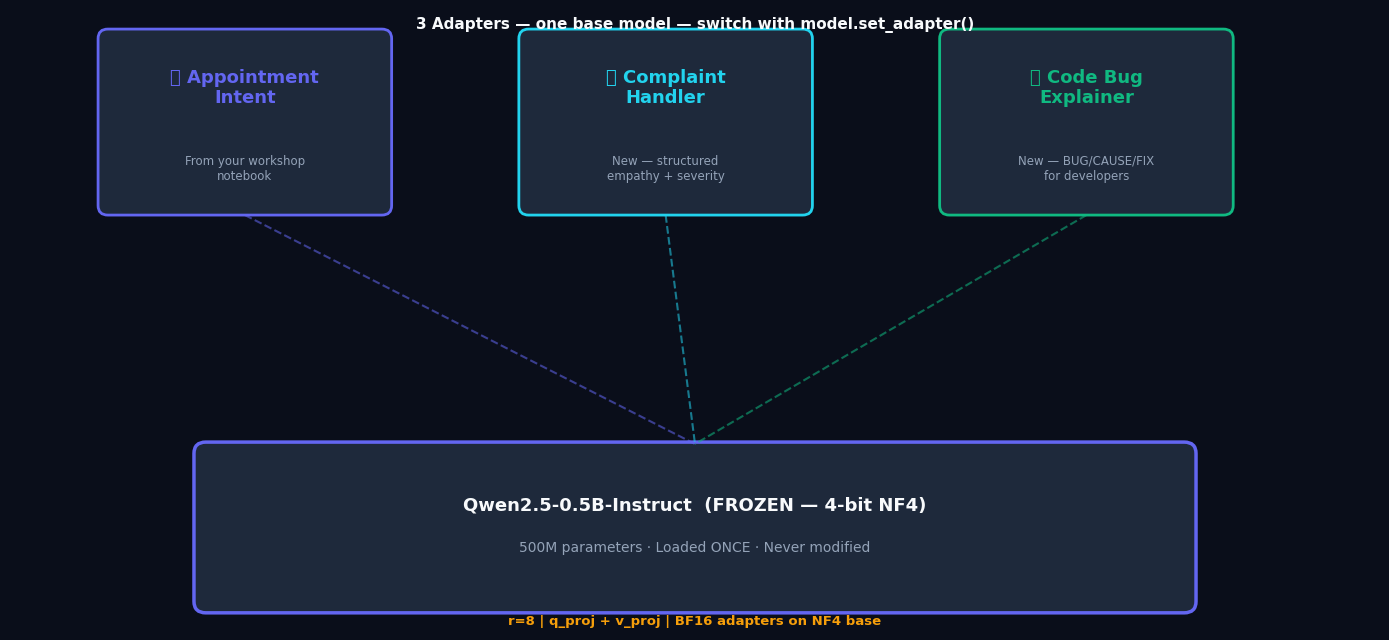

In [ ]:
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 6.5))
fig.patch.set_facecolor("#0A0E1A"); ax.set_facecolor("#0A0E1A")
ax.axis("off"); ax.set_xlim(0, 14); ax.set_ylim(0, 6.5)

base = FancyBboxPatch((2, 0.3), 10, 1.55, boxstyle="round,pad=0.12",
                       facecolor="#1E293B", edgecolor="#6366F1", linewidth=2.5)
ax.add_patch(base)
ax.text(7, 1.25, "Qwen2.5-0.5B-Instruct  (FROZEN — 4-bit NF4)", ha="center",
        fontsize=13, fontweight="bold", color="#F8FAFC")
ax.text(7, 0.82, "500M parameters · Loaded ONCE · Never modified",
        ha="center", fontsize=10, color="#94A3B8")

adapters = [
    ("🏥 Appointment\nIntent", "#6366F1", "From your workshop\nnotebook"),
    ("💬 Complaint\nHandler", "#22D3EE", "New — structured\nempathy + severity"),
    ("🐛 Code Bug\nExplainer", "#10B981", "New — BUG/CAUSE/FIX\nfor developers"),
]
for i, (name, col, note) in enumerate(adapters):
    x = 1.0 + i * 4.3
    ax.plot([x+1.4, 7], [4.35, 1.95], color=col, lw=1.5, alpha=0.55, ls="--")
    ab = FancyBboxPatch((x, 4.45), 2.8, 1.75, boxstyle="round,pad=0.1",
                        facecolor="#1E293B", edgecolor=col, linewidth=2.0)
    ax.add_patch(ab)
    ax.text(x+1.4, 5.52, name, ha="center", fontsize=13, fontweight="bold",
            color=col, multialignment="center")
    ax.text(x+1.4, 4.72, note, ha="center", fontsize=8.5, color="#94A3B8",
            multialignment="center")

ax.text(7, 6.3, "3 Adapters — one base model — switch with model.set_adapter()",
        ha="center", fontsize=11, fontweight="bold", color="#F8FAFC")
ax.text(7, 0.05, "r=8 | q_proj + v_proj | BF16 adapters on NF4 base",
        ha="center", fontsize=9.5, color="#F59E0B", fontweight="bold")
plt.tight_layout(); plt.show()


## Step 6 — Train All 3 Adapters

In [ ]:
ALL_TASKS = [TASK_APPT, TASK_COMPLAINT, TASK_BUG]

def make_dataset(task):
    df = pd.DataFrame(task["data"])
    ds = Dataset.from_pandas(df)
    def fmt(ex):
        texts = []
        for inp, out in zip(ex["input"], ex["output"]):
            msgs = [
                {"role": "system",    "content": task["system"]},
                {"role": "user",      "content": inp},
                {"role": "assistant", "content": out},
            ]
            texts.append(tokenizer.apply_chat_template(
                msgs, tokenize=False, add_generation_prompt=False))
        return {"text": texts}
    return ds.map(fmt, batched=True, remove_columns=["input", "output"])


In [ ]:
def train_adapter(task, base_model, tokenizer):
    import inspect
    _cfg = set(inspect.signature(trl.SFTConfig.__init__).parameters)
    _trn = set(inspect.signature(trl.SFTTrainer.__init__).parameters)

    print(f"\n{'='*60}")
    print(f"  {task['emoji']}  {task['display']}  |  TRL {trl.__version__}")
    print(f"{'='*60}")

    dataset = make_dataset(task)
    print(f"  Dataset   : {len(dataset)} examples")

    model = prepare_model_for_kbit_training(base_model)
    model = get_peft_model(model, LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=0.05,
        target_modules=LORA_TARGETS, bias="none", task_type=TaskType.CAUSAL_LM,
    ))
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot= sum(p.numel() for p in model.parameters())
    print(f"  Trainable : {tr:,} / {tot:,}  ({100*tr/tot:.3f}%)")

    if "max_seq_length" not in _cfg and "max_seq_length" not in _trn:
        tokenizer.model_max_length = MAX_SEQ_LEN

    adapter_path = f"{ADAPTERS_DIR}/{task['name']}"
    cfg = dict(output_dir=adapter_path, num_train_epochs=TRAIN_EPOCHS,
               per_device_train_batch_size=BATCH_SIZE,
               gradient_accumulation_steps=GRAD_ACCUM, learning_rate=LR,
               logging_steps=10, save_strategy="no",
               fp16=False, bf16=True, report_to="none", dataloader_pin_memory=False)

    if   "warmup_ratio" in _cfg: cfg["warmup_ratio"] = 0.1
    elif "warmup_steps" in _cfg: cfg["warmup_steps"] = 10
    if "lr_scheduler_type"  in _cfg: cfg["lr_scheduler_type"]  = "cosine"
    if "max_seq_length"     in _cfg: cfg["max_seq_length"]     = MAX_SEQ_LEN
    if "dataset_text_field" in _cfg: cfg["dataset_text_field"] = "text"
    if "packing"            in _cfg: cfg["packing"]            = False

    sft_config = trl.SFTConfig(**cfg)
    tkw = dict(model=model, train_dataset=dataset, args=sft_config)
    if   "processing_class"  in _trn: tkw["processing_class"]  = tokenizer
    elif "tokenizer"         in _trn: tkw["tokenizer"]         = tokenizer
    if "max_seq_length"      in _trn: tkw["max_seq_length"]    = MAX_SEQ_LEN
    if "dataset_text_field"  in _trn: tkw["dataset_text_field"]= "text"

    trl.SFTTrainer(**tkw).train()

    model.save_pretrained(adapter_path)
    tokenizer.save_pretrained(adapter_path)
    files = [f for f in os.listdir(adapter_path) if f.endswith((".safetensors",".bin"))]
    mb = sum(os.path.getsize(os.path.join(adapter_path,f)) for f in files)/1e6
    print(f"  Saved → {adapter_path}  ({mb:.1f} MB)")
    del model; torch.cuda.empty_cache()
    return adapter_path

print("✅ train_adapter() ready — version-safe across all TRL releases")


✅ train_adapter() ready — version-safe across all TRL releases


In [ ]:
log = []
for task in ALL_TASKS:
    t0   = time.time()
    path = train_adapter(task, base_model, tokenizer)
    elapsed = time.time() - t0
    log.append({"task":task["display"], "emoji":task["emoji"], "min":elapsed/60, "path":path})
    print(f"  ⏱  {elapsed/60:.1f} min\n")

print("\n" + "="*60)
print("✅ ALL 3 ADAPTERS TRAINED!")
for l in log:
    print(f"  {l['emoji']}  {l['task']:25s}  {l['min']:.1f} min  →  {l['path']}")



  🏥  Appointment Intent  |  TRL 1.4.0


Map:   0%|          | 0/68 [00:00<?, ? examples/s]

  Dataset   : 68 examples


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable : 540,672 / 315,660,160  (0.171%)


...

  Dataset   : 21 examples
  Trainable : 540,672 / 315,660,160  (0.171%)


Adding EOS to train dataset:   0%|          | 0/21 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/21 [00:00<?, ? examples/s]

Step,Training Loss
10,3.345231


  Saved → ./adapters/code_bug_explainer  (1.1 MB)
  ⏱  0.5 min


✅ ALL 3 ADAPTERS TRAINED!
  🏥  Appointment Intent         1.1 min  →  ./adapters/appointment_intent
  💬  Complaint Handler          0.4 min  →  ./adapters/complaint_handler
  🐛  Code Bug Explainer         0.5 min  →  ./adapters/code_bug_explainer


## Step 7 — Load Adapters & Hot-Swap Demo

In [ ]:
print("Loading base model for demo...")
demo_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto")
demo_base.config.use_cache = False

print("Attaching all 3 adapters...")
demo_model = PeftModel.from_pretrained(
    demo_base, f"{ADAPTERS_DIR}/{ALL_TASKS[0]['name']}",
    adapter_name=ALL_TASKS[0]['name'])
for t in ALL_TASKS[1:]:
    demo_model.load_adapter(f"{ADAPTERS_DIR}/{t['name']}", adapter_name=t['name'])
    print(f"  ✅ {t['emoji']} {t['display']}")
demo_model.eval()
print(f"\n🎉 3 adapters loaded | VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")


Loading base model for demo...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Attaching all 3 adapters...
  ✅ 💬 Complaint Handler
  ✅ 🐛 Code Bug Explainer

🎉 3 adapters loaded | VRAM: 1.22 GB


In [ ]:
def run_adapter(model, task, user_input, max_new=120):
    model.set_adapter(task["name"])
    msgs = [{"role":"system","content":task["system"]},
            {"role":"user","content":user_input}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new,
                             do_sample=False, pad_token_id=tokenizer.eos_token_id)
    new = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new, skip_special_tokens=True).strip()

print("✅ run_adapter() ready")


✅ run_adapter() ready


### 🔴 Live Demos — One model, three experts

In [ ]:
# ── 🏥 Appointment Intent ─────────────────────────────────────────────────────
print("█"*55)
print("  🏥  APPOINTMENT INTENT ADAPTER")
print("█"*55)
tests = [
    "Move my Tuesday appointment to Thursday",
    "Block out my entire Monday morning please",
    "Can you play some music while I wait?",
    "Good morning, I need some help",
    "That is all I needed, thank you!",
]
for msg in tests:
    intent = run_adapter(demo_model, TASK_APPT, msg, max_new=15)
    print(f"  [{intent}]  ←  {msg}")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


███████████████████████████████████████████████████████
  🏥  APPOINTMENT INTENT ADAPTER
███████████████████████████████████████████████████████
  [CANCELL_APPOINTMENTS]  ←  Move my Tuesday appointment to Thursday
  [BLOCK_SLOTS]  ←  Block out my entire Monday morning please
  [CANCLE_APPOINTMENTS]  ←  Can you play some music while I wait?
  [UNSUBSCRIBE]  ←  Good morning, I need some help
  [CLOSING_CONVERSATION]  ←  That is all I needed, thank you!


In [ ]:
# ── 💬 Complaint Handler ──────────────────────────────────────────────────────
print("█"*55)
print("  💬  COMPLAINT HANDLER ADAPTER")
print("█"*55)
complaint = (
    "I ordered a birthday cake for my daughter's party tomorrow "
    "and it has just arrived completely squashed. The party starts "
    "in 4 hours! I paid £80 for this!"
)
print(f"Customer: {complaint}\n")
print(run_adapter(demo_model, TASK_COMPLAINT, complaint, max_new=180))


███████████████████████████████████████████████████████
  💬  COMPLAINT HANDLER ADAPTER
███████████████████████████████████████████████████████
Customer: I ordered a birthday cake for my daughter's party tomorrow and it has just arrived completely squashed. The party starts in 4 hours! I paid £80 for this!

**SEVERITY:** **MEDIUM**
**EMOTION:** **Frustration**
**RESPONSE:** **Thank you for your patience. We understand that we have had some issues with your order. Please rest assured that we will work to resolve any problems promptly. In the meantime, please keep an eye on the cake as it is ready to be served. If there is anything else we can do to assist you, please let us know. We value your business and would like to make sure your daughter’s celebration is a success.**

This response acknowledges the customer's frustration while also offering a solution-oriented approach to address their concerns.


In [ ]:
# ── 🐛 Code Bug Explainer ─────────────────────────────────────────────────────
print("█"*55)
print("  🐛  CODE BUG EXPLAINER ADAPTER")
print("█"*55)
buggy_code = "for item in shopping_cart:\n    if item['price'] < 0:\n        shopping_cart.remove(item)"
print(f"Code:\n{buggy_code}\n")
print(run_adapter(demo_model, TASK_BUG, buggy_code, max_new=180))


███████████████████████████████████████████████████████
  🐛  CODE BUG EXPLAINER ADAPTER
███████████████████████████████████████████████████████
Code:
for item in shopping_cart:
    if item['price'] < 0:
        shopping_cart.remove(item)

BUG: The condition `if item['price'] < 0:` checks for negative prices, which could lead to an infinite loop.
CAUSE: This is due to the use of `remove()` method, which removes items from the list based on their index, without checking if they are valid (i.e., not None).
FIX: Add a check before calling `remove()` to ensure that the item exists before removing it. For example:

```python
for item in shopping_cart:
    if item['price'] < 0:
        # Check if the item exists before removing it
        if item.get('price') != -1:
            shopping_cart.remove(item)
```

This ensures that only items with positive prices are removed from the cart.


## Step 8 — Base Model vs Each Adapter

In [ ]:
def run_base(model, task, user_input, max_new=100):
    model.disable_adapter_layers()
    msgs = [{"role":"system","content":task["system"]},
            {"role":"user","content":user_input}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new,
                             do_sample=False, pad_token_id=tokenizer.eos_token_id)
    new = out[0][inputs["input_ids"].shape[1]:]
    result = tokenizer.decode(new, skip_special_tokens=True).strip()
    model.enable_adapter_layers()
    return result

# CMP = [
#     (TASK_APPT,      "Reschedule my appointment with Dr. Ahmed to next week"),
#     (TASK_COMPLAINT, "The software I paid £300 for crashes every time I open it. I need help."),
#     (TASK_BUG,       "result = []\nfor i in range(10):\n    result.append(i*i)\nprint(result[10])"),
# ]

rows = []
for task, inp in CMP:
    base_out    = run_base(demo_model, task, inp, max_new=80)
    adapter_out = run_adapter(demo_model, task, inp, max_new=150)
    rows.append({"task":task["display"],"emoji":task["emoji"],
                 "input":inp[:70]+"..." if len(inp)>70 else inp,
                 "base":base_out[:220], "adapter":adapter_out[:350]})
    print(f"  ✅ {task['emoji']} {task['display']}")

html = [
    "<style>.ct{border-collapse:collapse;width:100%;font-size:12px;font-family:monospace}",
    ".ct th{background:#1E293B;color:#6366F1;padding:8px 10px;text-align:left}",
    ".ct td{border:1px solid #334155;padding:8px 10px;vertical-align:top}",
    ".ct tr:nth-child(even) td{background:#0F172A}.ct tr:odd td{background:#1E293B}",
    ".b{color:#F43F5E}.a{color:#10B981}.i{color:#F59E0B}.l{font-weight:bold;color:#94A3B8}</style>",
    "<table class='ct'><tr><th>Task</th><th>Input</th><th>❌ Base model</th><th>✅ With adapter</th></tr>",
]
for r in rows:
    html.append(f"<tr><td class='l'>{r['emoji']} {r['task']}</td><td class='i'>{r['input']}</td>"
                f"<td class='b'>{r['base']}</td><td class='a'>{r['adapter']}</td></tr>")
html.append("</table>")
display(HTML("".join(html)))


  ✅ 🏥 Appointment Intent
  ✅ 🏥 Appointment Intent
  ✅ 🏥 Appointment Intent
  ✅ 🏥 Appointment Intent
  ✅ 🏥 Appointment Intent
  ✅ 💬 Complaint Handler
  ✅ 💬 Complaint Handler
  ✅ 💬 Complaint Handler
  ✅ 💬 Complaint Handler
  ✅ 💬 Complaint Handler
  ✅ 💬 Complaint Handler
  ✅ 💬 Complaint Handler
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer
  ✅ 🐛 Code Bug Explainer


Task,Input,❌ Base model,✅ With adapter
🏥 Appointment Intent,Reschedule my appointment with Dr. Ahmed to next Wednesday at 4 PM,RESCHEDULE_APPOINTMENTS,RESCHEDULE_APPOINTMENTS
🏥 Appointment Intent,Cancel my dental appointment tomorrow morning,CANCle_APPOINTMENTS,CANCLE_APPOINTMENTS
🏥 Appointment Intent,Book a cardiology consultation for Friday afternoon,CANCLE_APPOINTMENTS,CANCELL_APPOINTMENT
🏥 Appointment Intent,Move my therapy session from Monday to Thursday evening,CANCLE_APPOINTMENTS,CANCELL_APPOINTMENTS
🏥 Appointment Intent,I need the earliest available appointment for skin allergy treatment,CANCLE_APPOINTMENTS,UNBLOCK_SLOTS
💬 Complaint Handler,The software I paid £300 for crashes every time I open it. I need help...,SEVERITY: HIGH EMOTION: Very frustrated RESPONSE: We understand how frustrating it is to have your software crash multiple times each time you open it. Please rest assured that we will work with you to find a solution th,**SEVERITY:** CRITICAL **EMOTION:** Extremely frustrated **RESPONSE:** We understand how frustrating it is to have your software crash multiple times each time you open it. Our priority is to resolve any issues quickly so that we can provide you with a smooth and reliable experience. Please rest assured that we will investigate the issue thorough
💬 Complaint Handler,My broadband has been down for 4 days and I work remotely.,SEVERITY: [MEDIUM] EMOTION: [satisfied] RESPONSE: [Your support team will contact you to resolve the issue promptly.],SEVERITY: MEDIUM EMOTION: Satisfied RESPONSE: We understand how frustrating it can be to have your broadband service disrupted due to unforeseen circumstances like remote work. Our team is working hard to resolve any issues quickly and efficiently. Please keep us updated on progress as soon as possible.
💬 Complaint Handler,I was charged twice for the same hotel booking and nobody is respondin...,SEVERITY: HIGH EMOTION: low RESPONSE: I'm really sorry to hear that you're experiencing issues with our service. We understand how frustrating it can be when things don't go as planned. Please know that we take your feed,SEVERITY: HIGH EMOTION: Satisfied RESPONSE: I'm here to help! Please let me know if you need any assistance or have any other concerns. We're committed to resolving your issue promptly.
💬 Complaint Handler,The food delivery arrived cold and completely spilled inside the bag.,SEVERITY: LOW EMOTION: Cold and cold RESPONSE: We understand how you feel. Please rest assured that we will handle it as soon as possible to ensure your satisfaction. We apologize for any inconvenience caused and will do,"SEVERITY: CRITICAL EMOTION: Cold and spilling food is not acceptable. RESPONSE: We understand that you may be upset with the service, but we will ensure it's handled properly. Our team will check for any damage or contamination before proceeding. Please rest assured that we take your feedback seriously."
💬 Complaint Handler,I cancelled my subscription but your company keeps charging my card.,SEVERITY: MEDIUM EMOTION: [frustrated] RESPONSE: I'm here to help! Could you please confirm if there's an error with your account? We'll need to verify your details again before proceeding. Thank you for your patience.,"SEVERITY: MEDIUM EMOTION: [disappointed] RESPONSE: I'm sorry to hear you're experiencing this issue. We understand that cancellations can be stressful, especially when there's no immediate resolution. Please know that we will work with you to find an appropriate solution as quickly as possible. If you need any assistance or have any questions, feel"


In [ ]:
CMP = [

    # =========================
    # Appointment Tasks
    # =========================

    (
        TASK_APPT,
        "Reschedule my appointment with Dr. Ahmed to next Wednesday at 4 PM"
    ),

    (
        TASK_APPT,
        "Cancel my dental appointment tomorrow morning"
    ),

    (
        TASK_APPT,
        "Book a cardiology consultation for Friday afternoon"
    ),

    (
        TASK_APPT,
        "Move my therapy session from Monday to Thursday evening"
    ),

    (
        TASK_APPT,
        "I need the earliest available appointment for skin allergy treatment"
    ),

    # =========================
    # Complaint Tasks
    # =========================

    (
        TASK_COMPLAINT,
        "The software I paid £300 for crashes every time I open it. I need help."
    ),

    (
        TASK_COMPLAINT,
        "My broadband has been down for 4 days and I work remotely."
    ),

    (
        TASK_COMPLAINT,
        "I was charged twice for the same hotel booking and nobody is responding."
    ),

    (
        TASK_COMPLAINT,
        "The food delivery arrived cold and completely spilled inside the bag."
    ),

    (
        TASK_COMPLAINT,
        "I cancelled my subscription but your company keeps charging my card."
    ),

    (
        TASK_COMPLAINT,
        "Your support team ignored my emails for a week."
    ),

    (
        TASK_COMPLAINT,
        "The laptop stopped working after just one day of use."
    ),

    # =========================
    # Bug Explainer Tasks
    # =========================

    (
        TASK_BUG,
        """result = []
for i in range(10):
    result.append(i*i)

print(result[10])"""
    ),

    (
        TASK_BUG,
        """numbers = [1, 2, 3]
copy_numbers = numbers

copy_numbers.append(4)

print(numbers)"""
    ),

    (
        TASK_BUG,
        """def add_item(item, items=[]):
    items.append(item)
    return items"""
    ),

    (
        TASK_BUG,
        """user = get_user(user_id)
print(user.name)"""
    ),

    (
        TASK_BUG,
        """query = "SELECT * FROM users WHERE name = '" + username + "'" """
    ),

    (
        TASK_BUG,
        """x = 0.1 + 0.2

if x == 0.3:
    print("equal")"""
    ),

    (
        TASK_BUG,
        """for item in my_list:
    if item < 0:
        my_list.remove(item)"""
    ),

    (
        TASK_BUG,
        """def factorial(n):
    return n * factorial(n - 1)"""
    ),

    (
        TASK_BUG,
        """items = [[]] * 3

items[0].append(1)

print(items)"""
    ),

    (
        TASK_BUG,
        """import threading

counter = 0

def increment():
    global counter
    counter += 1"""
    ),

    # =========================
    # Hard / Tricky Cases
    # =========================

    (
        TASK_BUG,
        """data = [[1, 2], [3, 4]]

copy_data = data.copy()

copy_data[0][0] = 99

print(data)"""
    ),

    (
        TASK_BUG,
        """if user_input.lower == 'yes':
    proceed()"""
    ),

    (
        TASK_BUG,
        """df = df[df['status'] == 'active']
df['score'] = df['score'] * 2"""
    ),

    (
        TASK_BUG,
        """import json

config = json.load('settings.json')"""
    ),

    (
        TASK_BUG,
        """today = datetime.now()
yesterday = today - 1"""
    ),

    (
        TASK_BUG,
        """for (var i = 0; i < 5; i++) {
    setTimeout(() => console.log(i), 1000);
}"""
    ),
]

In [ ]:
def run_base(model, task, user_input, max_new=100):
    model.disable_adapter_layers()
    msgs = [{"role":"system","content":task["system"]},
            {"role":"user","content":user_input}]
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new,
                             do_sample=False, pad_token_id=tokenizer.eos_token_id)
    new = out[0][inputs["input_ids"].shape[1]:]
    result = tokenizer.decode(new, skip_special_tokens=True).strip()
    model.enable_adapter_layers()
    return result

# CMP = [
#     (TASK_APPT,      "Reschedule my appointment with Dr. Ahmed to next week"),
#     (TASK_COMPLAINT, "The software I paid £300 for crashes every time I open it. I need help."),
#     (TASK_BUG,       "result = []\nfor i in range(10):\n    result.append(i*i)\nprint(result[10])"),
# ]

rows = []
for task, inp in CMP:
    base_out    = run_base(demo_model, task, inp, max_new=80)
    adapter_out = run_adapter(demo_model, task, inp, max_new=150)
    rows.append({"task":task["display"],"emoji":task["emoji"],
                 "input":inp[:70]+"..." if len(inp)>70 else inp,
                 "base":base_out[:220], "adapter":adapter_out[:350]})
    print(f"  ✅ {task['emoji']} {task['display']}")

html = [
    "<style>.ct{border-collapse:collapse;width:100%;font-size:12px;font-family:monospace}",
    ".ct th{background:#1E293B;color:#6366F1;padding:8px 10px;text-align:left}",
    ".ct td{border:1px solid #334155;padding:8px 10px;vertical-align:top}",
    ".ct tr:nth-child(even) td{background:#0F172A}.ct tr:odd td{background:#1E293B}",
    ".b{color:#F43F5E}.a{color:#10B981}.i{color:#F59E0B}.l{font-weight:bold;color:#94A3B8}</style>",
    "<table class='ct'><tr><th>Task</th><th>Input</th><th>❌ Base model</th><th>✅ With adapter</th></tr>",
]
for r in rows:
    html.append(f"<tr><td class='l'>{r['emoji']} {r['task']}</td><td class='i'>{r['input']}</td>"
                f"<td class='b'>{r['base']}</td><td class='a'>{r['adapter']}</td></tr>")
html.append("</table>")
display(HTML("".join(html)))


## Step 9 — 🎮 Try It Yourself

In [ ]:
# ── Pick any adapter and test your own input ──────────────────────────────────
MY_TASK  = TASK_BUG      # swap to TASK_APPT or TASK_COMPLAINT
MY_INPUT = """
users = get_users()
for user in users:
    send_email(user.email)
    users.remove(user)
"""

print(f"Task  : {MY_TASK['emoji']} {MY_TASK['display']}")
print(f"Input : {MY_INPUT.strip()[:100]}")
print()
print(run_adapter(demo_model, MY_TASK, MY_INPUT.strip(), max_new=250))


## Summary

| Adapter | Dataset source | Examples | Output type |
|---------|---------------|----------|-------------|
| 🏥 Appointment Intent | Your workshop notebook | 68 | Single intent label |
| 💬 Complaint Handler | New | 55 | SEVERITY / EMOTION / RESPONSE |
| 🐛 Code Bug Explainer | New | 55 | BUG / CAUSE / FIX |

**The key lesson:** `model.set_adapter("appointment_intent")` is all it takes to switch between a medical scheduler, a customer empathy expert, and a debugging engineer — using one frozen 500M-parameter model loaded once.
